In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

print("Tudo certo")

Tudo certo


In [2]:
#FINAL
df_anual = pd.read_csv("data/final/resumo_anual_pb.csv", sep=';')
df_MENSAL = pd.read_csv("data/final/resumo_anual_pb.csv", sep=';')

#PROCESSADAS
df_ibge_proc = pd.read_csv("data/processed/ibge/populacao_uf_2015_2025.csv", sep=';')
df_sih_mensal = pd.read_csv("data/processed/sih/sih_pb_2015_01_saude_mental.csv", sep=';')

,ANO_CMPT,internacoes
0,2015,77
1,2016,126
2,2017,21
3,2018,66
4,2019,40
5,2020,83
6,2021,21
7,2022,116
8,2023,65
9,2024,152


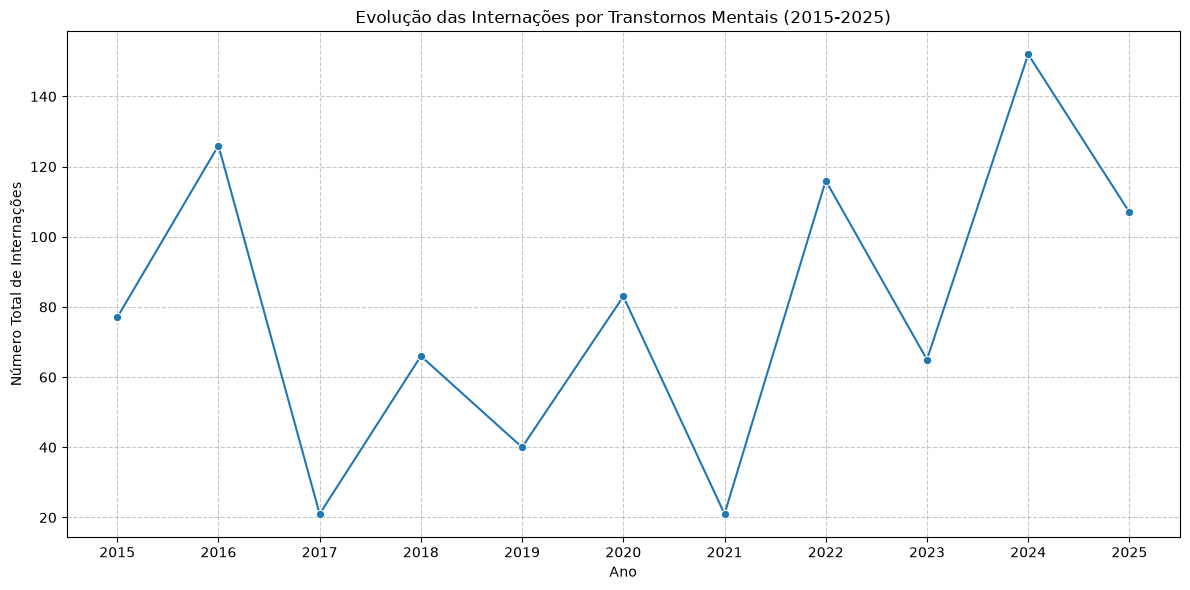

In [3]:
from matplotlib import rcsetup

internacoes_por_ano = df_anual.groupby('ANO_CMPT')['internacoes'].sum().reset_index()

display(internacoes_por_ano)

plt.figure(figsize=(12, 6))
sns.lineplot(x='ANO_CMPT', y='internacoes', data=internacoes_por_ano, marker='o')
plt.title('Evolução das Internações por Transtornos Mentais (2015-2025)')
plt.xlabel('Ano')
plt.ylabel('Número Total de Internações')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(internacoes_por_ano['ANO_CMPT'])
plt.tight_layout()
plt.show()

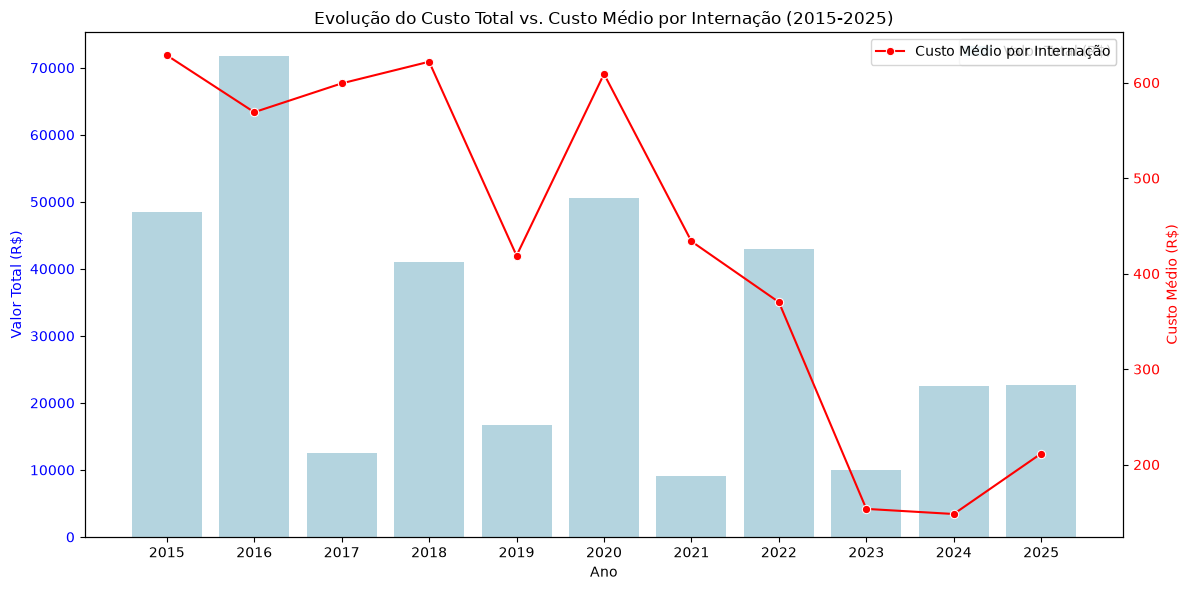


--- Análise de Permanência Média ---


C:\Users\Ricardo\AppData\Local\Temp\ipykernel_34516\411262620.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ANO_CMPT', y='media_dias_internacao', data=dias_anuais, palette='viridis')


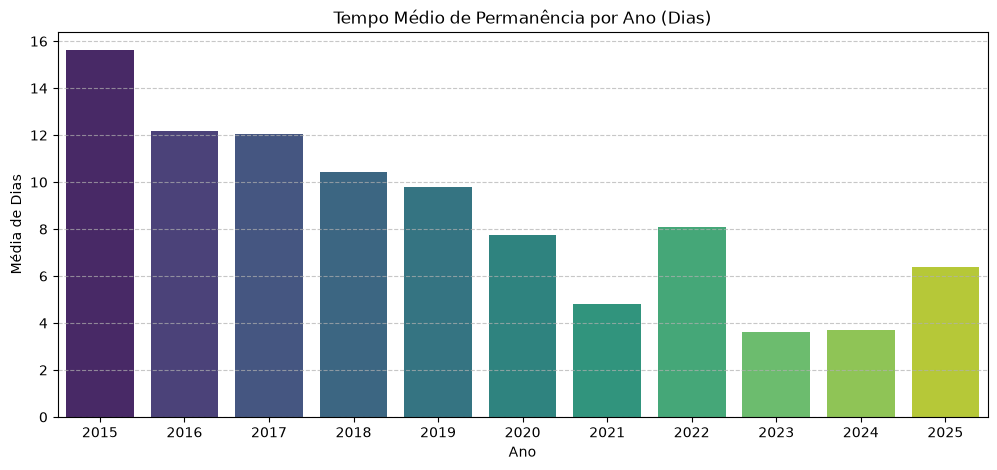

In [4]:

custos_anuais = df_anual.groupby('ANO_CMPT').agg({
    'valor_total': 'sum',
    'internacoes': 'sum'
}).reset_index()

custos_anuais['custo_medio'] = custos_anuais['valor_total'] / custos_anuais['internacoes']

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(x='ANO_CMPT', y='valor_total', data=custos_anuais, ax=ax1, color='lightblue', label='Valor Total (R$)')
ax1.set_ylabel('Valor Total (R$)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
sns.lineplot(x=range(len(custos_anuais)), y='custo_medio', data=custos_anuais, ax=ax2, marker='o', color='red', label='Custo Médio por Internação')
ax2.set_ylabel('Custo Médio (R$)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Evolução do Custo Total vs. Custo Médio por Internação (2015-2025)')
ax1.set_xlabel('Ano')
fig.tight_layout()
plt.show()

print("\n--- Análise de Permanência Média ---")
dias_anuais = df_anual.groupby('ANO_CMPT')['media_dias_internacao'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(x='ANO_CMPT', y='media_dias_internacao', data=dias_anuais, palette='viridis')
plt.title('Tempo Médio de Permanência por Ano (Dias)')
plt.xlabel('Ano')
plt.ylabel('Média de Dias')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

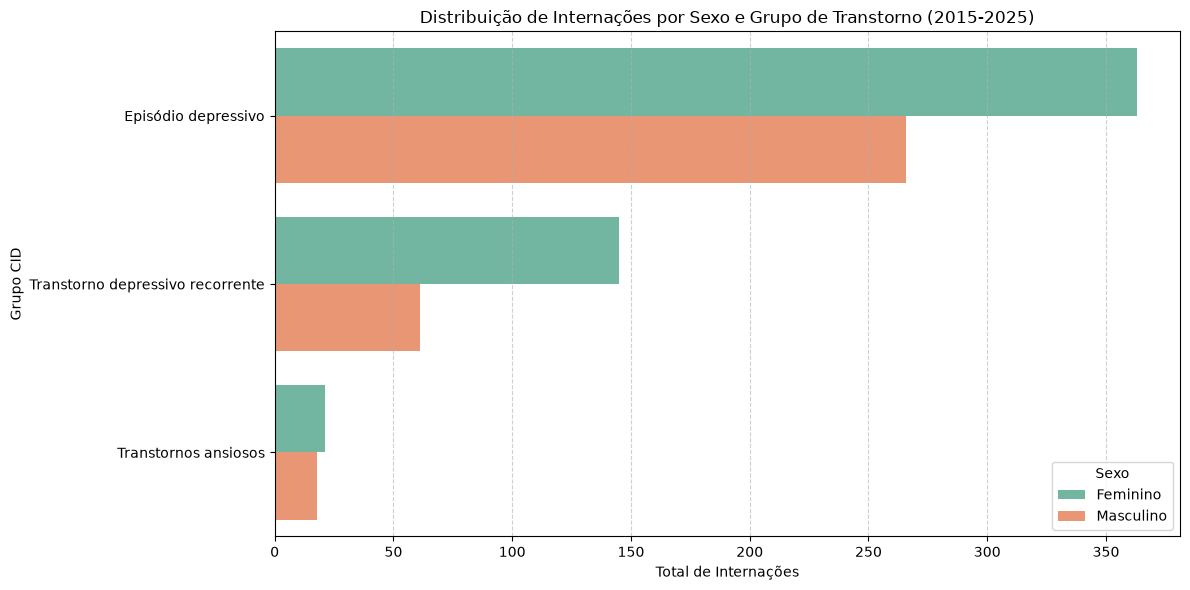

In [5]:

try:
    df_completo = pd.read_parquet('data/processed/sih/sih_pb_2015_2025_saude_mental.parquet')

    def mapear_cid(cid):
        if str(cid).startswith('F32'): return 'Episódio depressivo'
        if str(cid).startswith('F33'): return 'Transtorno depressivo recorrente'
        if str(cid).startswith(('F40', 'F41')): return 'Transtornos ansiosos'
        return 'Outros'

    df_completo['GRUPO_CID'] = df_completo['DIAG_PRINC'].apply(mapear_cid)

    df_sexo = df_completo[df_completo['GRUPO_CID'] != 'Outros'].copy()

    df_sexo['SEXO_LABEL'] = df_sexo['SEXO'].map({1: 'Masculino', 3: 'Feminino', '1': 'Masculino', '3': 'Feminino'})

    sexo_cid = df_sexo.groupby(['SEXO_LABEL', 'GRUPO_CID']).size().reset_index(name='total')

    plt.figure(figsize=(12, 6))
    sns.barplot(x='total', y='GRUPO_CID', hue='SEXO_LABEL', data=sexo_cid, palette='Set2')
    plt.title('Distribuição de Internações por Sexo e Grupo de Transtorno (2015-2025)')
    plt.xlabel('Total de Internações')
    plt.ylabel('Grupo CID')
    plt.legend(title='Sexo')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Erro na análise: {e}')

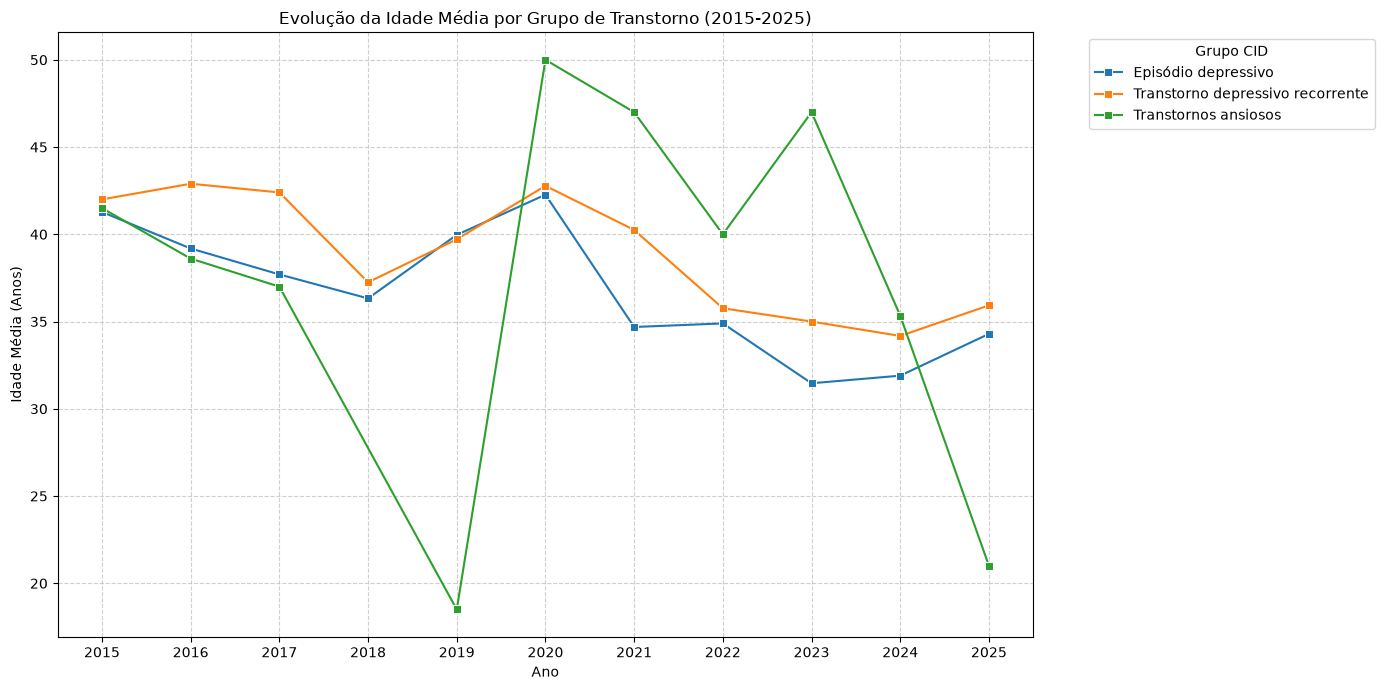

In [6]:
df_completo['IDADE'] = pd.to_numeric(df_completo['IDADE'], errors='coerce')

df_idade_limpo = df_completo.dropna(subset=['IDADE'])

perfil_etario = df_idade_limpo[df_idade_limpo['GRUPO_CID'] != 'Outros'].groupby(['ANO_CMPT', 'GRUPO_CID'])['IDADE'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(x='ANO_CMPT', y='IDADE', hue='GRUPO_CID', data=perfil_etario, marker='s')

plt.title('Evolução da Idade Média por Grupo de Transtorno (2015-2025)')
plt.xlabel('Ano')
plt.ylabel('Idade Média (Anos)')
plt.legend(title='Grupo CID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(perfil_etario['ANO_CMPT'].unique())
plt.tight_layout()
plt.show()

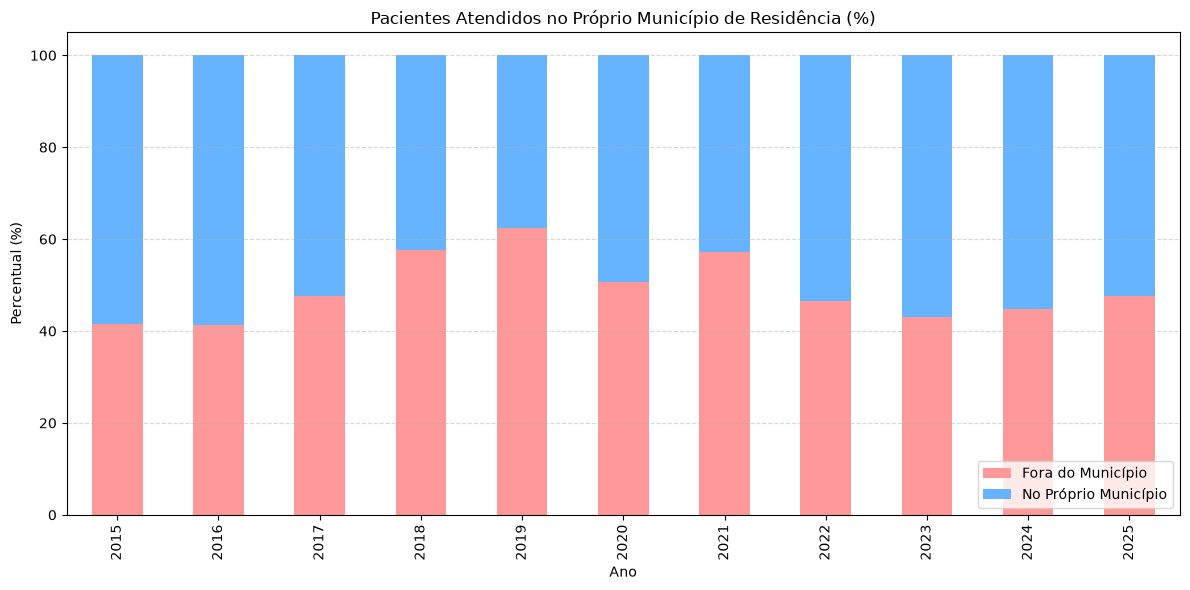

In [7]:
df_completo['MESMO_MUNICIPIO'] = df_completo['MUNIC_RES'] == df_completo['MUNIC_MOV']

fluxo_anual = df_completo.groupby(['ANO_CMPT', 'MESMO_MUNICIPIO']).size().unstack(fill_value=0)
fluxo_anual_percent = fluxo_anual.div(fluxo_anual.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 6))
fluxo_anual_percent.plot(kind='bar', stacked=True, ax=plt.gca(), color=['#ff9999','#66b3ff'])

plt.title('Pacientes Atendidos no Próprio Município de Residência (%)')
plt.xlabel('Ano')
plt.ylabel('Percentual (%)')
plt.legend(['Fora do Município', 'No Próprio Município'], loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [8]:
import os
trends_path = None
for root, dirs, files in os.walk('/content'):
    for file in files:
        if 'google_trends' in file.lower() and file.endswith('.csv'):
            trends_path = os.path.join(root, file)
            break

try:
    df_pop = df_ibge_proc
    pop_pb = df_pop[df_pop['uf'] == 'PB'].copy()
    pop_pb.columns = [c.upper() for c in pop_pb.columns]
    pop_total = pop_pb['POPULACAO'].iloc[0] if not pop_pb.empty else 4039277

    internacoes_totais = df_anual.groupby('ANO_CMPT')['internacoes'].sum().reset_index()
    internacoes_totais['TAXA_100K'] = (internacoes_totais['internacoes'] / pop_total) * 100000

    if trends_path:
        df_trends = pd.read_csv(trends_path, skiprows=1)

        df_trends.columns = ['date', 'INTERESSE']
        df_trends['date'] = pd.to_datetime(df_trends['date'], errors='coerce')
        df_trends = df_trends.dropna(subset=['date'])
        df_trends['ANO_CMPT'] = df_trends['date'].dt.year

        trends_anual = df_trends.groupby('ANO_CMPT')['INTERESSE'].mean().reset_index()
        trends_anual.columns = ['ANO_CMPT', 'INTERESSE_BUSCA']

        df_corr = pd.merge(internacoes_totais, trends_anual, on='ANO_CMPT')

        fig, ax1 = plt.subplots(figsize=(12, 5))
        sns.lineplot(data=internacoes_totais, x='ANO_CMPT', y='internacoes', marker='o', ax=ax1, label='Internações', color='blue')
        ax2 = ax1.twinx()
        sns.lineplot(data=trends_anual, x='ANO_CMPT', y='INTERESSE_BUSCA', marker='s', ax=ax2, label='Buscas Google', color='purple')
        plt.title('Volume de Internações vs. Interesse no Google (2015-2025)')
        ax1.set_ylabel('Internações', color='blue')
        ax2.set_ylabel('Interesse (Trends)', color='purple')
        plt.grid(True, alpha=0.3)
        plt.show()

        if not df_corr.empty:
            corr_val = df_corr['INTERESSE_BUSCA'].corr(df_corr['internacoes'])
            print(f'Correlação de Pearson entre buscas e internações: {corr_val:.2f}')

            print('\n--- CONCLUSÃO FINAL ---')
            print(f'1. O crescimento das internações (PB) foi acompanhado por uma taxa por 100k habitantes de {internacoes_totais["TAXA_100K"].mean():.2f}.')
            if corr_val > 0.6:
                print('2. Existe uma forte correlação positiva entre o interesse de busca e as internações reais.')
            else:
                print('2. A correlação com o Google Trends é moderada ou baixa, indicando outros fatores influenciando as internações.')
    else:
        print('Arquivo de Google Trends não encontrado.')

except Exception as e:
    print(f'Erro no processamento: {e}')

Arquivo de Google Trends não encontrado.
